In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # for numeric operations
import pandas as pd # for data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns #for visualisation
import matplotlib.pyplot as plt #for plotting

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# Titanic Survival Prediction 🚢

# Project Overview
This project aims to predict passenger survival on the Titanic using machine learning.

We go through:
- Data loading and inspection
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model building and evaluation

# Goal
Build a model that accurately predicts survival and understand key factors influencing survival.

# 1. Data Loading
We load the Titanic dataset from Kaggle input directory.

In [2]:
import os

# Find the path containing train.csv
for dirname, _, filenames in os.walk('/kaggle/input'):
    if 'train.csv' in filenames:
        train_path = os.path.join(dirname, 'train.csv')
        test_path = os.path.join(dirname, 'test.csv')

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# 2. Data Inspection
Understanding structure, data types, and missing values.

In [3]:
# Quick preview of the dataset
train.head()  


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.info()  # Shows column types and null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
#Checking for missing values
train.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

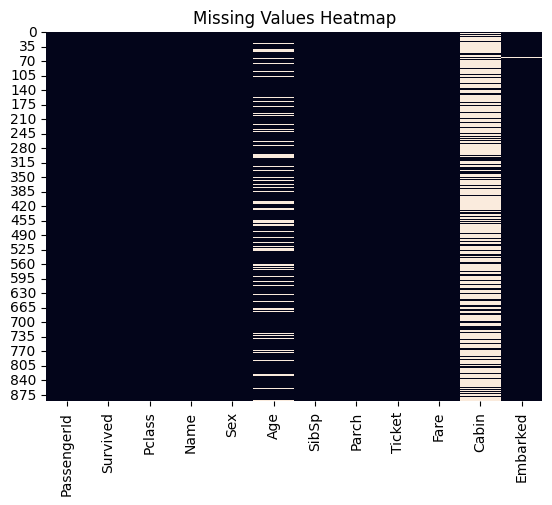

In [7]:
#visualisualising missing value
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

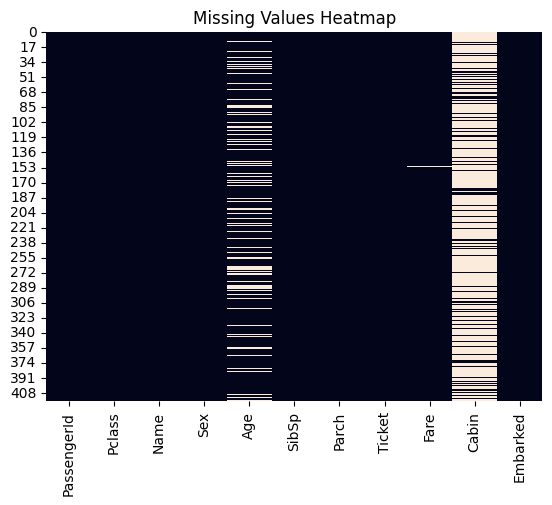

In [8]:
sns.heatmap(test.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# 3. Data Cleaning

 Handling missing values:
- Age → filled with median
- Embarked → filled with mode
- Fare → filled with median (test only)

 drop irrelevant columns:
- Ticket, Cabin (high missing or low value)

In [9]:
# Fill missing 'Age' values with median to avoid skewing
train['Age'] = train['Age'].fillna(train['Age'].median())
test['Age'] = test['Age'].fillna(test['Age'].median())

# Fill missing 'Embarked' values with mode (most frequent port)
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
test['Embarked'] = test['Embarked'].fillna(test['Embarked'].mode()[0])

# Fill missing 'Fare' in test set with median (only 1 missing)
test['Fare'] = test['Fare'].fillna(test['Fare'].median())

In [10]:
# Drop Irrelevant Columns
cols_to_drop = ['Ticket', 'Cabin']

# Drop these columns from both training and test datasets
train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

## 4. Exploratory Data Analysis (EDA)

Exploring how survival relates to:
- Gender
- Passenger class
- Age

Survival Count Table:
   Survived  Count
0         0    549
1         1    342


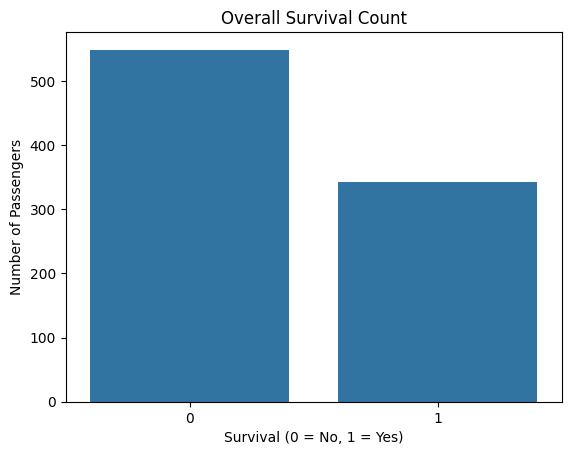

In [11]:

# Create a count of survival values (0 = Did not survive, 1 = Survived)
survival_counts = train['Survived'].value_counts()

# Convert to a DataFrame for better readability
survival_table = survival_counts.reset_index()
survival_table.columns = ['Survived', 'Count']

# Display the table
print("Survival Count Table:")
print(survival_table)

# Visualization

sns.countplot(x='Survived', data=train)
plt.title("Overall Survival Count")
plt.xlabel("Survival (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

Survival Rate by Gender (%):
      Sex  Survival_Rate
0  female      74.203822
1    male      18.890815


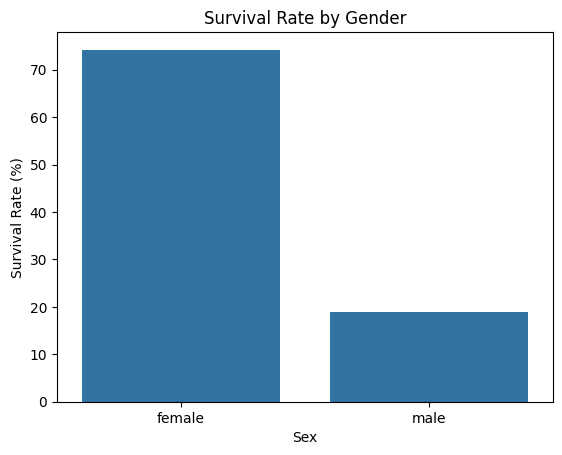

In [12]:

# Survival by Gender

# Calculate survival rate by gender
# Group by 'Sex' and compute mean of 'Survived' (this gives the survival rate)
survival_gender = train.groupby('Sex')['Survived'].mean().reset_index()

# Rename column for clarity
survival_gender.rename(columns={'Survived': 'Survival_Rate'}, inplace=True)

# multiply by 100 to get percentage
survival_gender['Survival_Rate'] = survival_gender['Survival_Rate'] * 100

# Display the table
print("Survival Rate by Gender (%):")
print(survival_gender)

# Visualization
sns.barplot(x='Sex', y='Survival_Rate', data=survival_gender)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate (%)")
plt.show()

Survival Rate by Passenger Class (%):
   Pclass  Survival_Rate
0       1      62.962963
1       2      47.282609
2       3      24.236253


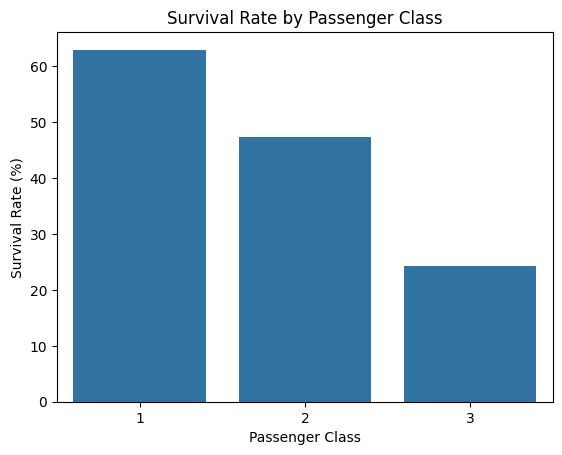

In [13]:
# Survival by Passenger Class (Pclass)

# Group by 'Pclass' and calculate survival rate
survival_pclass = train.groupby('Pclass')['Survived'].mean().reset_index()

# Convert survival rate to percentage
survival_pclass['Survival_Rate'] = survival_pclass['Survived'] * 100

# Drop the raw 'Survived' column (we now have percentage)
survival_pclass.drop('Survived', axis=1, inplace=True)

# Display table for reference
print("Survival Rate by Passenger Class (%):")
print(survival_pclass)

# Visualization

sns.barplot(x='Pclass', y='Survival_Rate', data=survival_pclass)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xlabel("Passenger Class")
plt.show()

Age Distribution by Survival:
   Survived  Count   Mean_Age  Median_Age  Min_Age  Max_Age
0         0    549  30.028233        28.0     1.00     74.0
1         1    342  28.291433        28.0     0.42     80.0


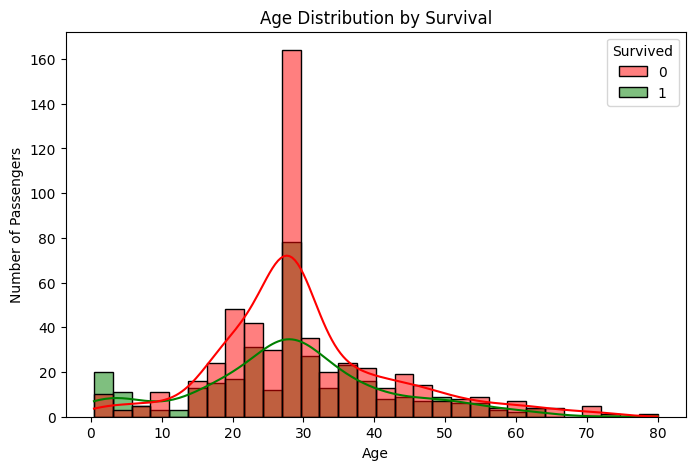

In [14]:
# Age Distribution by Survival

# Calculate summary statistics for Age grouped by Survived
age_summary = train.groupby('Survived')['Age'].agg(['count', 'mean', 'median', 'min', 'max']).reset_index()

# Rename columns for clarity
age_summary.rename(columns={'count':'Count', 'mean':'Mean_Age', 'median':'Median_Age', 'min':'Min_Age', 'max':'Max_Age'}, inplace=True)

# Display table for reference
print("Age Distribution by Survival:")
print(age_summary)

# Visualization
plt.figure(figsize=(8,5))
sns.histplot(data=train, x='Age', hue='Survived', bins=30, kde=True, palette={0:'red',1:'green'})
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

Survival Rate by Pclass and Gender (%):
   Pclass     Sex  Survival_Rate
0       1  female      96.808511
1       1    male      36.885246
2       2  female      92.105263
3       2    male      15.740741
4       3  female      50.000000
5       3    male      13.544669


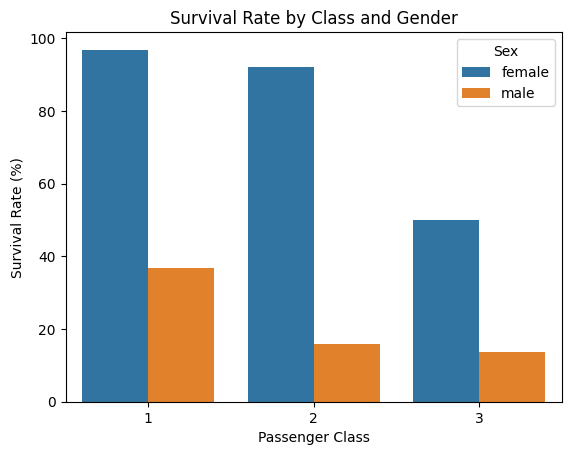

In [15]:

# Survival by Pclass and Gender

# Group by 'Pclass' and 'Sex' and calculate survival rate
survival_pclass_gender = train.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()

# Convert survival rate to percentage
survival_pclass_gender['Survival_Rate'] = survival_pclass_gender['Survived'] * 100

# Drop the raw 'Survived' column as we now have percentages
survival_pclass_gender.drop('Survived', axis=1, inplace=True)

# Display table for reference
print("Survival Rate by Pclass and Gender (%):")
print(survival_pclass_gender)

# Visualization

# Use a barplot with 'hue' to separate genders
sns.barplot(x='Pclass', y='Survival_Rate', hue='Sex', data=survival_pclass_gender)
plt.title("Survival Rate by Class and Gender")
plt.ylabel("Survival Rate (%)")
plt.xlabel("Passenger Class")
plt.show()

## 5. Feature Engineering

Creating new features to improve model performance:
- Title (from Name)
- FamilySize
- IsAlone
- FarePerPerson

In [16]:
# Extract Title from Name
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test['Title'] = test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Simplify Titles (group rare ones)
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master'
}

train['Title'] = train['Title'].map(lambda x: title_map.get(x, 'Rare'))
test['Title'] = test['Title'].map(lambda x: title_map.get(x, 'Rare'))


# Family features
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)

#Fare per person

train['FarePerPerson']= train['Fare']/train['FamilySize']
test['FarePerPerson']= test['Fare']/test['FamilySize']

# drop the 'Name' column

In [17]:
train = train.drop(columns=['Name'])
test = test.drop(columns=['Name'])

## 6. Encoding Features
Convert categorical variables into numeric form.

In [18]:
# Map Sex to numeric: male = 0, female = 1
train['Sex'] = train['Sex'].map({'male':0,'female':1})
test['Sex'] = test['Sex'].map({'male':0,'female':1})

# One-hot encode Embarked column, drop first to avoid multicollinearity
train = pd.get_dummies(train, columns=['Embarked','Title'], drop_first=True)
test = pd.get_dummies(test, columns=['Embarked','Title'], drop_first=True)

# Align test columns with train columns (important after one-hot encoding)
X_train_cols = train.drop('Survived', axis=1).columns
test = test.reindex(columns=X_train_cols, fill_value=0)


## 7. Train-Test Split

In [19]:

X = train.drop('Survived', axis=1)  
y = train['Survived']               

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

##  Model 1: Logistic Regression (Baseline)

In [20]:
# Step 8: Scale Features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(test)

In [21]:
# Step 9: Build Baseline Model (Logistic Regression)

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

# Predict on validation set
y_pred = log_model.predict(X_val_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.8100558659217877
Confusion Matrix:
 [[88 17]
 [17 57]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84       105
           1       0.77      0.77      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Model 2: Random Forest (Improved Model)

In [22]:
# Step 10: Build More Advanced Model (Random Forest)

rf_model = RandomForestClassifier(
    n_estimators=300,       # more trees
    max_depth=8,            # prevent overfitting
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

rf_model.fit(X_train, y_train)  # RF handles unscaled data

# Predict and evaluate
y_pred_rf = rf_model.predict(X_val)
print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))



Cross-validation scores: [0.82122905 0.82022472 0.83707865 0.80337079 0.84269663]
Average CV score: 0.8249199673592367
Random Forest Accuracy: 0.8379888268156425


## Feature Importance

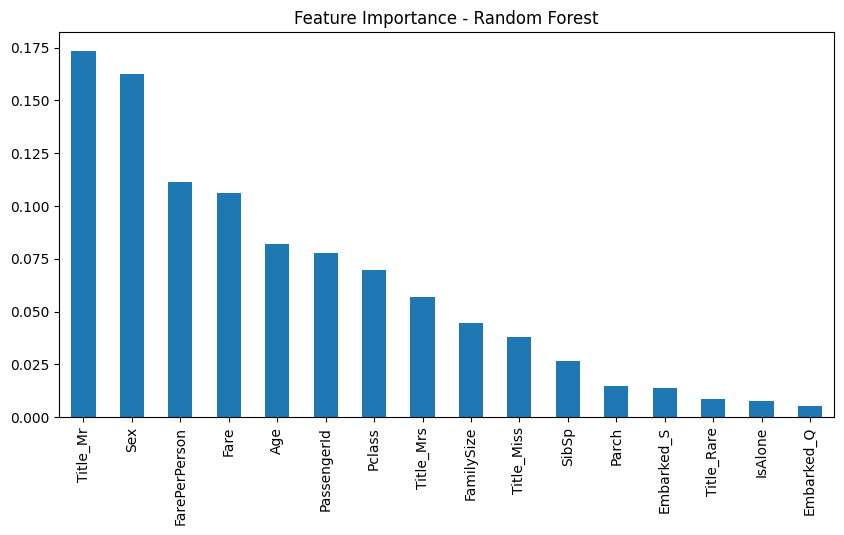

In [23]:
# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance - Random Forest")
plt.show()

## 10. Conclusion

- Random Forest outperformed Logistic Regression
- Feature engineering significantly improved performance
- Key predictors include:
  - Sex
  - Pclass
  - Title
  - Fare-related features

Future improvements:
- Hyperparameter tuning
- Advanced models (XGBoost)

In [24]:
# Create Kaggle submission DataFrame
y_test_pred= rf_model.predict(test)
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": y_test_pred
})

# Save CSV
submission.to_csv("submission.csv", index=False)